# 01 - Get the data and have a look at it

Goal of this notebook: download MVSA-Single, work out which tweets have a usable label, clean the text,
make a train / val / test split and save everything in one small csv.

**About the data.** MVSA-Single (Niu et al., MMM 2016) is a set of ~5k tweets where every tweet has some text
and one image, labelled positive / negative / neutral. The original site asks you to fill a form, so I use a
community copy on the Hugging Face Hub (`xwycyj/MVSA-Single`). It is a 211 MB zip, so I never unzip it - the
later notebooks read straight out of the zip file. That keeps disk usage low.

The dataset is for research use. It is not redistributed in this repo, the notebook just downloads it.

In [1]:
import io
import os
import re
import json
import zipfile
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

SEED = 42
DATA_DIR = Path("../data")
SAMPLE_DIR = Path("../static/samples")
DATA_DIR.mkdir(exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

BASE = "https://huggingface.co/datasets/xwycyj/MVSA-Single/resolve/main"
# the env vars are only there so I can point the notebook at a local copy if the hub is down
ZIP_URL = os.environ.get("MVSA_ZIP_URL", f"{BASE}/data.zip")
TEST_URL = os.environ.get("MVSA_TEST_URL", f"{BASE}/test.json")

## Download
Streamed to disk in chunks so it does not sit in RAM. Re-running the cell skips files that already exist.

In [2]:
def download(url, dest, chunk=1 << 20):
    dest = Path(dest)
    if dest.exists() and dest.stat().st_size > 0:
        print(f"{dest.name} is already here ({dest.stat().st_size / 1e6:.1f} MB), skipping")
        return dest

    part = dest.with_name(dest.name + ".part")
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        done = 0
        with open(part, "wb") as f:
            for block in r.iter_content(chunk):
                f.write(block)
                done += len(block)
                if total:
                    print(f"\r{dest.name}: {done / 1e6:.0f} / {total / 1e6:.0f} MB", end="")
    os.replace(part, dest)
    print()
    return dest


zip_path = download(ZIP_URL, DATA_DIR / "data.zip")
test_path = download(TEST_URL, DATA_DIR / "test.json")

data.zip: 211 / 211 MB



## What is inside the zip?

I could not open the archive before writing this, so instead of assuming a layout the notebook looks at it.
Tweets are expected as `<id>.txt` + `<id>.jpg`. Labels can come from json files in the format of `test.json`
(`{"12": {"text_label": 2, "img_label": 0, "label": 0}, ...}`) or from the original `labelResultAll.txt`.

In [3]:
zf = zipfile.ZipFile(zip_path)
names = [n for n in zf.namelist() if not n.startswith("__MACOSX") and not n.endswith("/")]
print(len(names), "files in the archive")
print(names[:6])

pair_re = re.compile(r"(?:^|/)(\d+)\.(jpg|jpeg|png|txt)$", re.I)
found = {}
for n in names:
    m = pair_re.search(n)
    if m:
        slot = "txt" if m.group(2).lower() == "txt" else "img"
        found.setdefault(int(m.group(1)), {})[slot] = n

pairs = {k: v for k, v in found.items() if "img" in v and "txt" in v}
print(len(pairs), "tweets with both a text file and an image")
print("json files in the zip:", [n for n in names if n.lower().endswith(".json")])
print("label file in the zip:", [n for n in names if n.lower().endswith("labelresultall.txt")])

9738 files in the archive
['data/1.jpg', 'data/1.txt', 'data/10.jpg', 'data/10.txt', 'data/100.jpg', 'data/100.txt']
4869 tweets with both a text file and an image
json files in the zip: []
label file in the zip: []


## Labels

The json files store integers. I worked out the mapping from the data itself rather than trusting a guess:
when the text label is 2 and the image label is 0, the final label is almost always 0; text 2 + image 1 gives 1;
and text 0 + image 0 gives 0. MVSA is known for tweets with a neutral text and an emotional image, so
**0 = positive, 1 = negative, 2 = neutral** is the reading that fits (and 0 is the biggest class, like
positive is in MVSA-Single). If you know better, change the dict below - it is the only place it lives.

In [4]:
LABEL_NAMES = {0: "positive", 1: "negative", 2: "neutral"}


def read_label_json(raw):
    data = json.loads(raw)
    out = {}
    for k, v in data.items():
        if isinstance(v, dict) and "label" in v and str(k).isdigit():
            out[int(k)] = LABEL_NAMES[int(v["label"])]
    return out


labels = {}
for n in names:
    if n.lower().endswith(".json"):
        try:
            got = read_label_json(zf.read(n))
            print(f"{n}: {len(got)} labels")
            labels.update(got)
        except Exception as e:
            print(f"skipping {n} ({e})")

got = read_label_json(test_path.read_bytes())
print(f"test.json: {len(got)} labels")
labels.update(got)
print("labels from json files:", len(labels))

test.json: 487 labels
labels from json files: 487


If the json files did not give enough labelled tweets, fall back to the original annotation file
(`labelResultAll.txt`, one line per tweet: `id<TAB>text_label,image_label`). Same rule everybody uses:
if both agree take it, if one side is neutral take the other, drop the tweet if they clash.

In [5]:
def combine(text_lab, img_lab):
    if text_lab == img_lab:
        return text_lab
    if text_lab == "neutral":
        return img_lab
    if img_lab == "neutral":
        return text_lab
    return None


label_file = [n for n in names if n.lower().endswith("labelresultall.txt")]
if len(labels) < 1000 and label_file:
    print("not many json labels, reading", label_file[0])
    fallback = {}
    for line in zf.read(label_file[0]).decode("utf-8", errors="ignore").splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2 or not parts[0].isdigit():
            continue
        sides = parts[1].split(",")
        if len(sides) != 2 or not all(s in LABEL_NAMES.values() for s in sides):
            continue
        lab = combine(sides[0], sides[1])
        if lab:
            fallback[int(parts[0])] = lab
    labels = fallback

print("usable labels:", len(labels))
usable = sorted(set(labels) & set(pairs))
print("tweets with label + text + image:", len(usable))

usable labels: 487
tweets with label + text + image: 487


## Text cleaning

Tweets are messy: urls, @mentions, RT, hashtags. I keep the words of a hashtag (`#happy` -> `happy`) because
they often carry the sentiment. The same function is copied into `app.py` so the web app treats input the same way.

In [6]:
def clean_text(t):
    t = t.lower()
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"\brt\b", " ", t)
    t = t.replace("#", " ")
    t = re.sub(r"[^a-z0-9' ]+", " ", t)
    return re.sub(r"\s+", " ", t).strip()


rows = []
for pid in usable:
    raw = zf.read(pairs[pid]["txt"]).decode("utf-8", errors="ignore").strip()
    rows.append({
        "id": pid,
        "text_raw": raw,
        "text": clean_text(raw),
        "label": labels[pid],
        "img_name": pairs[pid]["img"],
    })

df = pd.DataFrame(rows)
df.head(8)

,id,text_raw,text,label,img_name
0,1,How I feel today #legday #jelly #aching #gym,how i feel today legday jelly aching gym,positive,data/1.jpg
1,4,#escort We have a young and energetic team and...,escort we have a young and energetic team and ...,positive,data/4.jpg
2,15,Awesome record. Keepin the night energetic ??,awesome record keepin the night energetic,positive,data/15.jpg
3,28,RT @Beltrew: Enthusiastic hello from the kids ...,enthusiastic hello from the kids of zarqa jord...,positive,data/28.jpg
4,38,RT @Footy_Jokes: Mario finally has a smile on ...,mario finally has a smile on his face,positive,data/38.jpg
5,41,3 New Tips to Handling Your Anger #anger #issu...,3 new tips to handling your anger anger issues...,negative,data/41.jpg
6,51,Martha said for Valentine's Day she wanted a h...,martha said for valentine's day she wanted a h...,positive,data/51.jpg
7,55,ߤߤȤ뤫# #abandoned #ruins #haikyo #urbex #дäˤȿꤿ,abandoned ruins haikyo urbex,negative,data/55.jpg


## Split
Stratified 80 / 10 / 10 so the small neutral class shows up in every part. This is my own split, not the official one.

In [7]:
train_df, rest_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(rest_df, test_size=0.5, stratify=rest_df["label"], random_state=SEED)

df["split"] = "train"
df.loc[val_df.index, "split"] = "val"
df.loc[test_df.index, "split"] = "test"

df.to_csv(DATA_DIR / "dataset.csv", index=False)
print(df["split"].value_counts())

split
train    389
test      49
val       49
Name: count, dtype: int64


## A quick look

label
positive    290
negative    141
neutral      56
Name: count, dtype: int64
label
positive    0.595
negative    0.290
neutral     0.115
Name: count, dtype: float64


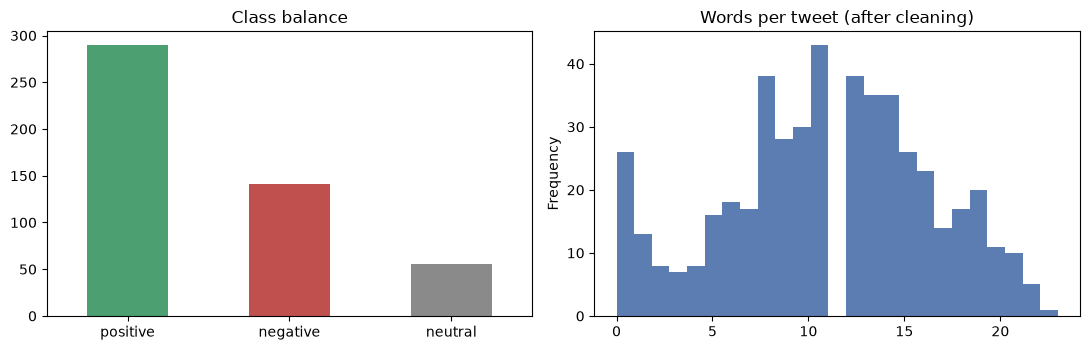

In [8]:
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum()).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
counts.plot.bar(ax=axes[0], color=["#4c9f70", "#c0504d", "#8a8a8a"][: len(counts)])
axes[0].set_title("Class balance")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

df["text"].str.split().str.len().plot.hist(bins=25, ax=axes[1], color="#5b7db1")
axes[1].set_title("Words per tweet (after cleaning)")
plt.tight_layout()
plt.show()

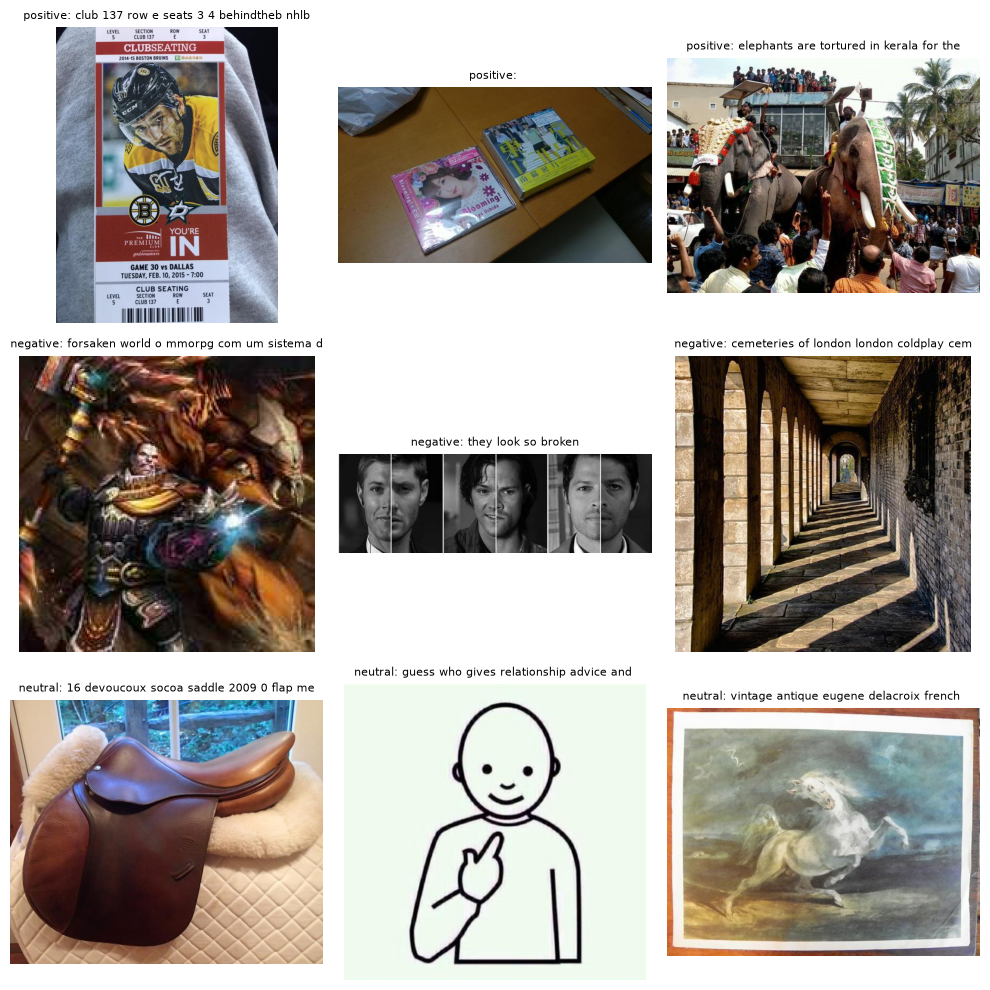

In [9]:
# one row per class, three random tweets each
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for r, lab in enumerate(counts.index[:3]):
    subset = df[df["label"] == lab].sample(3, random_state=SEED)
    for c, (_, row) in enumerate(subset.iterrows()):
        img = Image.open(io.BytesIO(zf.read(row["img_name"]))).convert("RGB")
        axes[r, c].imshow(img)
        axes[r, c].axis("off")
        axes[r, c].set_title(f"{lab}: " + row["text"][:40], fontsize=8)
plt.tight_layout()
plt.show()

Things I noticed: the classes are quite unbalanced (neutral is small), many tweets are very short, and the image and
the text often disagree about the mood. That is the whole reason to try fusion, and also why I will look at
macro-F1 and not just accuracy.

## Save a few examples for the web app

Nine tweets from the **test** split (three per class) get copied to `static/samples/` so the demo has
one-click examples. The web app never sees them during training. Text is the cleaned text, so no @handles end up in the demo.

In [10]:
picked = []
for lab in df["label"].unique():
    pool = df[(df["split"] == "test") & (df["label"] == lab) & (df["text"].str.split().str.len() >= 4)]
    picked.append(pool.sample(min(3, len(pool)), random_state=SEED))
picked = pd.concat(picked)

for _, row in picked.iterrows():
    img = Image.open(io.BytesIO(zf.read(row["img_name"]))).convert("RGB")
    img.thumbnail((420, 420))
    img.save(SAMPLE_DIR / f"{row['id']}.jpg", quality=88)

picked[["id", "text", "label"]].to_csv(SAMPLE_DIR / "samples.csv", index=False)
print(len(picked), "samples saved")

9 samples saved
